<a href="https://colab.research.google.com/github/eftekhar-hossain/Disaster_IEEE-Access/blob/main/damage_identification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Libraries

In [2]:
%%time
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import seaborn as sns
import re,nltk,json
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
from sklearn.metrics import average_precision_score,roc_auc_score, roc_curve, precision_recall_curve
from tensorflow.keras.utils import plot_model
np.random.seed(42)
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.tokenize import ToktokTokenizer
import string, spacy,unicodedata, random
from bs4 import BeautifulSoup
class color: # Text style
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'
import warnings
warnings.filterwarnings('ignore')
### Pretrained Word Embeddings
pretrained_path = "/content/drive/MyDrive/Research/Anik/Multimodal"
# dataset_path = "/content/drive/MyDrive/Colab Notebooks/MSC Presentation Tasks/Disaster Response/Images/"
# folder_path = "/content/drive/MyDrive/Colab Notebooks/MSC Presentation Tasks/Disaster Response/"
models_path = "/content/drive/MyDrive/Research/Anik/Multimodal"


folder_path = "/content/drive/MyDrive/Research/Dataset Collection/"
# models_path = "/content/drive/MyDrive/TaheriThesis/Dataset/Multimodal Sentiment/Models/"
# results_path = "/content/drive/MyDrive/TaheriThesis/Dataset/Multimodal Sentiment/Results/"
dataset_path = "/content/drive/MyDrive/Research/Dataset Collection/unzipped/Without text"

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


CPU times: user 6.62 s, sys: 1.26 s, total: 7.88 s
Wall time: 11.6 s


In [3]:
from keras.preprocessing import image
from keras.applications.vgg16 import VGG16
from keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.resnet50 import ResNet50
from keras.applications.vgg16 import preprocess_input
from keras.preprocessing.text import Tokenizer
from keras.layers import Dense, GlobalAveragePooling2D, Embedding, LSTM, multiply
from keras.models import Model
from keras import preprocessing, Input
from tensorflow import keras
from keras.models import Sequential
#Import from keras_preprocessing not from keras.preprocessing
# from keras_preprocessing.image import ImageDataGenerator
from keras.layers import Dense, Activation, Flatten, Dropout, BatchNormalization
from keras.layers import Conv2D, MaxPooling2D
from keras import regularizers, optimizers
from tensorflow.keras.models import load_model
import itertools
from PIL import Image, ImageFile
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Concatenate, Dense, Input, LSTM, Embedding, Dropout, Activation, GRU, Flatten
from tensorflow.keras.layers import Bidirectional, GlobalMaxPool1D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Convolution1D,MaxPooling1D,Conv1D
from tensorflow.keras import initializers, regularizers, constraints, optimizers, layers
from tensorflow.keras.layers import Add, BatchNormalization, Activation, Dropout
from tensorflow.keras.optimizers import RMSprop,Adam,SGD,Nadam
keras.backend.clear_session()

In [4]:
from google.colab import drive
from google.colab import files
import zipfile
import os
import shutil

In [ ]:
# uploaded = files.upload()

# Step 3: Unzip the File
zip_file_name = '/content/drive/MyDrive/Research/Dataset Collection/dataset_pic.zip'  # Get the uploaded zip file name

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('/content/unzipped_images')

# Step 4: Save to Google Drive
drive_folder_path = '/content/drive/MyDrive/Research/Dataset Collection/unzipped'
shutil.move('/content/unzipped_images', drive_folder_path)

print(f"Files have been moved to {drive_folder_path}")

Files have been moved to /content/drive/MyDrive/Research/Dataset Collection/unzipped


In [5]:
import pandas as pd
import os

# Load the CSV file
csv_path = '/content/drive/MyDrive/Research/Dataset Collection/Dataset_text.csv'  # Adjust the path as per your setup
df = pd.read_csv(csv_path)

# Assuming images are in the 'unzipped_images' folder
images_folder = "/content/drive/MyDrive/Research/Dataset Collection/unzipped/Without text/"  # Adjust path if necessary


In [6]:
from sklearn.utils import shuffle

df = shuffle(df, random_state=42)


In [7]:
train_ratio = 0.6
val_ratio = 0.2
test_ratio = 0.2

num_samples = len(df)
train_size = int(train_ratio * num_samples)
val_size = int(val_ratio * num_samples)
test_size = num_samples - train_size - val_size


In [8]:
train_data, val_test = train_test_split(df, train_size=train_ratio, random_state=42)
valid_data, test_data = train_test_split(val_test, train_size=val_ratio/(val_ratio + test_ratio), random_state=42)

#Fetching Dataset

In [ ]:
# train_data = pd.read_excel(folder_path+'train.xlsx')
# test_data = pd.read_csv(folder_path+'test.xlsx')
# valid_data = pd.read_excel(main_path+'valid_new.xlsx')



train_data = pd.read_csv(folder_path+'train.csv')
valid_data = pd.read_csv(folder_path+'valid.csv')
test_data = pd.read_csv(folder_path+'test.csv')



In [9]:
train_data.columns

Index(['Image id', 'Caption', 'Label', 'Source', 'Domain', 'Unnamed: 5'], dtype='object')

In [10]:
train_data['Label'].value_counts()

Label
1    1631
0    1372
Name: count, dtype: int64

In [11]:
test_data['Label'].value_counts()

Label
1    573
0    429
Name: count, dtype: int64

In [12]:
valid_data['Label'].value_counts()

Label
1    546
0    455
Name: count, dtype: int64

In [13]:
null_label_count = df['Label'].isnull().sum()
null_label_count

0

In [ ]:
null_label_ids = df[df['Label'].isnull()]['Image id'].tolist()

print("Image IDs with null labels:")
print(null_label_ids)

Image IDs with null labels:
[]


In [14]:

train_data['label_name'] = train_data['Label'].replace({1:'Commercial', 0 : 'Non commercial'})
valid_data['label_name'] = valid_data['Label'].replace({1:'Commercial', 0 : 'Non commercial'})
test_data['label_name'] = test_data['Label'].replace({1:'Commercial', 0 : 'Non commercial'})


In [15]:
train_data = train_data.drop(['Source', 'Domain', 'Unnamed: 5'], axis = 1)

In [16]:
valid_data = valid_data.drop(['Source', 'Domain', 'Unnamed: 5'], axis = 1)
test_data = test_data.drop(['Source', 'Domain', 'Unnamed: 5'], axis = 1)

In [17]:
valid_data.head(5)

,Image id,Caption,Label,label_name
379,380,বিমূর্ত ব্যক্তিত্ব..\r\nআরসি থেকে সাজসজ্জা_ ❤️,1,Commercial
1233,1234,"প্লানঃ মেঘালয়, নাগাল্যান্ড।",0,Non commercial
3280,3281,টয়লেট টিস্যু দিয়ে স্মুদ মেকাপ বেস?? 😱😱,1,Commercial
2377,2378,৩ বান্ধবী যখন পিকচার তুলে,1,Commercial
2437,2438,১ টাকার এক্সের চিন্তা বাদ দিয়ে কাল থেকে আমাদের...,1,Commercial


In [18]:
import pandas as pd
from tensorflow.keras.utils import to_categorical

# Assuming `train_data` and `valid_data` are pandas DataFrames with 'Label' column

# Handle NaN values in train_data['Label']
train_data['Label'].fillna(0, inplace=True)  # Replace NaN with 1 (modify as needed)

# Handle NaN values in valid_data['Label']
valid_data['Label'].fillna(0, inplace=True)  # Replace NaN with 1 (modify as needed)
test_data['Label'].fillna(0, inplace=True)  # Replace NaN with 1 (modify as needed)
# Convert labels to one-hot encoded representation
#y_train = to_categorical(train_data['Label'])
#y_valid = to_categorical(valid_data['Label'])
#y_test = to_categorical(test_data['Label'])

In [19]:
print("Size of the training data ==> ", train_data.shape)
print("Size of the Test data ==>", test_data.shape)

Size of the training data ==>  (3003, 4)
Size of the Test data ==> (1002, 4)


In [ ]:
# Save split datasets to CSV
train_data.to_csv('/content/drive/MyDrive/Research/Dataset Collection/train.csv', index=False)
valid_data.to_csv('/content/drive/MyDrive/Research/Dataset Collection/valid.csv', index=False)
test_data.to_csv('/content/drive/MyDrive/Research/Dataset Collection/test.csv', index=False)


## Image Fetching

In [20]:
## collect image names from the folders
def create_img_array(img_dirct):
    all_imgs = []
    for root, j, files in os.walk(img_dirct):
        for file in files:
            file = root + '' + file
            all_imgs.append(file)
    return all_imgs

#def create_img_path(DF, Col_name, img_dir):
#    img_path = [img_dir + '' + name for name in DF[Col_name]]
#    return img_path

def create_img_path(DF, Col_name, img_dir):
    img_path = [os.path.join(img_dir, str(name)) for name in DF[Col_name]]
    return img_path


In [21]:
# Creating train, test and validation image path
train_img_path = create_img_path(train_data,'Image id', dataset_path)
valid_img_path = create_img_path(valid_data,'Image id', dataset_path)

In [22]:
test_img_path = create_img_path(test_data,'Image id', dataset_path)

In [23]:
# Function that returns image reading from the path
def get_input(path):
    # Loading image from given path
    # and resizing it to 150*150*3 format
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    img= tf.keras.utils.load_img(path, target_size=(150,150))
    # img.close()
    return(img)

# Takes in image and preprocess it
def process_input(img):
    # Converting image to array
    img_data =tf.keras.utils.img_to_array(img)
    # Adding one more dimension to array
    img_data = np.expand_dims(img_data, axis=0)
    #
    img_data = preprocess_input(img_data)
    #img_data = preprocess_input(img_data)
    return(img_data)


In [ ]:
# Create an array of training images
train_images = []
for n,i in enumerate(train_img_path):
  if os.path.exists(i + '.jpg'):
    input_img = get_input(i + '.jpg')
    process_img = process_input(input_img)
  # print(n)
  elif os.path.exists(i + '.png'):
    input_img = get_input(i + '.png')
    process_img = process_input(input_img)
  else:
    continue
  train_images.append(process_img[0])

In [ ]:
# Create an array of training images
valid_images = []
for n,i in enumerate(valid_img_path):
  #i = i[:-2]
  if os.path.exists(i + '.jpg'):
    input_img = get_input(i + '.jpg')
    process_img = process_input(input_img)
  # print(n)
  elif os.path.exists(i + '.png'):
    input_img = get_input(i + '.png')
    process_img = process_input(input_img)
  else:
    continue
  valid_images.append(process_img[0])

In [ ]:
# Create an array of training images
test_images = []
for n,i in enumerate(test_img_path):
  #i = i[:-2]
  if os.path.exists(i + '.jpg'):
    input_img = get_input(i + '.jpg')
    process_img = process_input(input_img)
  # print(n)
  elif os.path.exists(i + '.png'):
    input_img = get_input(i + '.png')
    process_img = process_input(input_img)
  else:
    continue
  test_images.append(process_img[0])

In [ ]:
len(test_images)

1002

In [ ]:
# convert into numpy array
train_image = np.array(train_images)

In [ ]:
valid_image = np.array(valid_images)

In [ ]:
test_image = np.array(test_images)

In [ ]:
import pickle as pkl
with open(dataset_path+'train.pkl','wb') as f:
    pkl.dump(train_image, f)

# with open(dataset_path+'test.pkl','wb') as f:
#     pkl.dump(test_image, f)

In [ ]:
import pickle as pkl
with open(dataset_path+'valid.pkl','wb') as f:
    pkl.dump(valid_image, f)

In [ ]:
import pickle as pkl


with open(dataset_path+'test.pkl','wb') as f:
    pkl.dump(test_image, f)

In [24]:
import pickle as pkl
with open(dataset_path+'train.pkl','rb') as f:
  train_image = pkl.load(f)
  print("Training Images:-- ",train_image.shape)

Training Images:--  (3003, 150, 150, 3)


In [25]:

with open(dataset_path+'valid.pkl','rb') as f:
  valid_image = pkl.load(f)
  print("Validation Images:-- ",valid_image.shape)

Validation Images:--  (1001, 150, 150, 3)


In [26]:
with open(dataset_path+'test.pkl','rb') as f:
  test_image = pkl.load(f)
  print("Test Images:-- ",test_image.shape)

Test Images:--  (1002, 150, 150, 3)


## One Hot Encoding

In [27]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

In [28]:
train_data['label_name'] = train_data['Label'].replace({1:'Commercial', 0 : 'Non commercial'})
valid_data['label_name'] = valid_data['Label'].replace({1:'Commercial', 0 : 'Non commercial'})
test_data['label_name'] = test_data['Label'].replace({1:'Commercial', 0 : 'Non commercial'})

In [29]:
# encoder=OneHotEncoder(sparse=False)

# encoded_labels = pd.DataFrame (encoder.fit_transform(train_data[['label']]))

# encoded_labels .columns = encoder.get_feature_names(['label'])

# train_data= pd.concat([train_data, encoded_labels ], axis=1)

import pandas as pd

# Define the list of categories for your Label_Sentiment variable
categories = ['Commercial', 'Non commercial']

# Perform one-hot encoding using get_dummies() function
encoded_labels = pd.get_dummies(train_data['label_name'], columns=categories, prefix='label_name')

# Concatenate the encoded labels with your original train_data DataFrame
train_data = pd.concat([train_data, encoded_labels], axis=1)

In [30]:
train_data.columns

Index(['Image id', 'Caption', 'Label', 'label_name', 'label_name_Commercial',
       'label_name_Non commercial'],
      dtype='object')

In [31]:
# train_data = train_data.rename(columns={'label_damaged_infrastructure':'damaged_infrastructure', 'label_damaged_nature':'damaged_nature',
#                                         'label_fires':'fires','label_flood':'flood',
#                                         'label_human_damage':'human_damage', 'label_non_damage':'non_damage'})


train_data = train_data.rename(columns={'label_name_Commercial':'Commercial',
                                        'label_name_Non commercial':'Non commercial'})


train_data

,Image id,Caption,Label,label_name,Commercial,Non commercial
2607,2608,এমন তুলতুলে আর কিছুই আপনার জীবনে নাই ।,1,Commercial,True,False
2108,2109,না আটকিয়ে ব্যঞ্জনবর্ণ পুরাটা বলতে পারলে পিৎজা...,1,Commercial,True,False
2548,2549,গরম খুব বেশী লাগলে এসে কিছুক্ষন ফ্রী AC খেয়ে ...,1,Commercial,True,False
2693,2694,এমব্রয়ডারির এবং সিকুইনের কাজ সহ,1,Commercial,True,False
1541,1542,বিশ্ব পর্যটন দিবস উপলক্ষে সারা বছর ঘুমের ফাকে ...,0,Non commercial,False,True
...,...,...,...,...,...,...
255,256,আলহামদুলিল্লাহ 🥰 কুরিয়ানা 👌💯🤝\r\nথেকে - খাগড়...,1,Commercial,True,False
93,94,সাগরিয়া চরের মানুষেরা এমনই! \nদেশের প্রত্যন্ত ...,1,Commercial,True,False
4442,4443,একটি সংক্ষিপ্ত কিন্তু ফলপ্রসূ ব্যবসায়িক ভ্রমণ...,0,Non commercial,False,True
3549,3550,২১ ফেব্রুয়ারি উপলক্ষে এত্তোগুলো ডিসকাউন্ট ঝটপট...,1,Commercial,True,False


In [32]:
train_data.columns

Index(['Image id', 'Caption', 'Label', 'label_name', 'Commercial',
       'Non commercial'],
      dtype='object')

In [33]:
train_data.Caption = train_data.Caption.astype(str)

## Text Cleaning

In [34]:

import locale
print(locale.getpreferredencoding())

import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding

UTF-8


In [35]:
!pip install emoji

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.4/431.4 kB 9.4 MB/s eta 0:00:00


In [ ]:
# stp_path = '/content/drive/MyDrive/TaheriThesis/Dataset/'
# stp = open(stp_path+'bangla_stopwords.txt','r',encoding='utf-8').read().split()

In [36]:
'''
Text Cleaning
'''
import emoji
import re

def remove_emojis(text):
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)


def text_cleaning(row):
   #to remove HTML tags
  text = BeautifulSoup(row, 'html.parser').get_text()
  d = re.sub(r'(https|http)?:\/\/(\w|\.|\/|\?|\=|\&|\%)*\b', '', text, flags=re.MULTILINE) #This line is for removing url
  post = d.replace('\n', '')
  post = d.replace('\r\n', '')
  post = post.replace('—', ' ')
  post = post.replace('।', ' ')
  text = ''.join([c for c in post if c not in string.punctuation])
  text= remove_emojis(text)
  # to remove special characters
  pattern = r'^\s*|\s\s*'
  text = re.sub(pattern, ' ', text).strip()
  # convert into lower case
  text = text.lower()
  # # Stopword
  # result = text.split()
  # text = [word.strip() for word in result if word not in stp ]
  # text =" ".join(text)

  return text

In [37]:
#Removing punctuations
train_data['cleaned'] = train_data['Caption'].apply(text_cleaning)
valid_data['cleaned'] = valid_data['Caption'].apply(text_cleaning)
test_data['cleaned'] = test_data['Caption'].apply(text_cleaning)


## Data samples after cleaning
print("Data samples after cleaning:\n")
for i in range(10):
  if i in train_data.index:
    print("Original Data:===\n",train_data.Caption[i],"\nCleaned Data:===\n",train_data.cleaned[i],)

Data samples after cleaning:

Original Data:===
 বড় বড় আইডিয়া কি শুধু বড় বড় শহর থেকেই আসে? দেশজুড়ে সেরা ‘আইডিয়াপ্রেনার’-দের খোঁজে আমরা এবার গিয়েছিলাম দিনাজপুরে!

জেলায় জেলায় স্মার্ট উদ্যোক্তা তৈরির লক্ষ্যে, দেশের ২০টি অঞ্চলে আইডিয়া ডিজাইন বুটক্যাম্পে পিচ সেশনের মাধ্যমে রুট লেভেল থেকে বাছাই করা হচ্ছে সেরা ২০টি দল। এখনও প্রতিটি অঞ্চল থেকে একটি করে মোট ১৮টি দলের সুযোগ আছে ইউনিক আইডিয়া দিয়ে বিজয়ী হওয়ার। আসছি আপনার জেলাতেও, আইডিয়া ও দল নিয়ে রেডি তো?

দিনাজপুরের আইডিয়া ডিজাইন বুটক্যাম্পের ছবিগুলো তুলেছেন ফটোগ্রাফার ইমরান হোসেন রুমি। 
Cleaned Data:===
 বড় বড় আইডিয়া কি শুধু বড় বড় শহর থেকেই আসে দেশজুড়ে সেরা ‘আইডিয়াপ্রেনার’দের খোঁজে আমরা এবার গিয়েছিলাম দিনাজপুরে জেলায় জেলায় স্মার্ট উদ্যোক্তা তৈরির লক্ষ্যে দেশের ২০টি অঞ্চলে আইডিয়া ডিজাইন বুটক্যাম্পে পিচ সেশনের মাধ্যমে রুট লেভেল থেকে বাছাই করা হচ্ছে সেরা ২০টি দল এখনও প্রতিটি অঞ্চল থেকে একটি করে মোট ১৮টি দলের সুযোগ আছে ইউনিক আইডিয়া দিয়ে বিজয়ী হওয়ার আসছি আপনার জেলাতেও আইডিয়া ও দল নিয়ে রেডি তো দিনাজপুরের আইডিয়া ডিজাইন বুটক্যাম্পের ছবিগুলো তুলেছেন ফটো

##Evaluation Metrics

In [38]:
'''Evaluation Parameters'''

def print_metrices(true,pred):
    print(confusion_matrix(true,pred))
    print(classification_report(true,pred))
    print("Accuracy : ",accuracy_score(true,pred))
    print("Precison : ",precision_score(true,pred, average = 'weighted'))
    print("Recall : ",recall_score(true,pred,  average = 'weighted'))
    print("F1 : ",f1_score(true,pred,  average = 'weighted'))

## Confusion Matrix

In [39]:
## Confusion matrix function
def con_mat(true,pred,class_names,model_name):
  cm = confusion_matrix(true,pred)
  #sns.set()
  plt.figure(figsize =(4, 3))
  ax = plt.subplot()
 # 'Greys', 'Purples', 'Blues', 'Greens', 'Oranges', 'Reds','YlOrBr', 'YlOrRd', 'OrRd', 'PuRd', 'RdPu', 'BuPu',
            #'GnBu', 'PuBu', 'YlGnBu', 'PuBuGn', 'BuGn', 'YlGn'
  sns.heatmap(cm, annot=True,fmt="d",cmap='YlOrRd', ax = ax,annot_kws={"size": 10},) #annot=True to annotate cells
  # labels, title and ticks
  ax.set_xlabel('Predicted labels',fontsize=10)
  ax.set_ylabel('True labels',fontsize=10)
  #ax.set_title(f'Confusion Matrix of {model_name}',fontsize=10)
  ax.xaxis.set_ticklabels(class_names, rotation=45); ax.yaxis.set_ticklabels(class_names, rotation=45);
  ax.xaxis.tick_top()
 # plt.savefig(folder_path + f"{model_name}.png",bbox_inches='tight',dpi =500)

In [40]:
from sklearn.utils import compute_class_weight
class_weights = compute_class_weight(
                                        class_weight = "balanced",
                                        classes = np.unique(train_data['Label']),
                                        y = train_data['Label']
                                    )
class_weights = dict(zip(np.unique(train_data['Label']), class_weights))
class_weights

{0: 1.094387755102041, 1: 0.9206008583690987}

#Textual Models

## Tokenizer

In [41]:
''' Tokenizer '''

def text_tokenizer(train_data,valid_data,test_data,vocabulary,max_len,sample_text_num):

  tokenizer = Tokenizer(num_words = vocabulary ,filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n-',
                        split=' ', char_level=False, oov_token='<oov>', document_count=0)
  tokenizer.fit_on_texts(train_data['cleaned'])
  word_index = tokenizer.word_index
  vocab_size = len(word_index)+1

  # Training Sequences
  train_sequences = tokenizer.texts_to_sequences(train_data['cleaned'])
  train_pad_sequences =  keras.preprocessing.sequence.pad_sequences(train_sequences, value=0.0, padding='post', maxlen= max_len)


  valid_sequences = tokenizer.texts_to_sequences(valid_data['cleaned'])
  valid_pad_sequences =  keras.preprocessing.sequence.pad_sequences(valid_sequences, value=0.0, padding='post', maxlen= max_len)

  # Test Sequences
  test_sequences = tokenizer.texts_to_sequences(test_data['cleaned'])
  test_pad_sequences =  keras.preprocessing.sequence.pad_sequences(test_sequences, value=0.0, padding='post', maxlen= max_len)


  print(color.BOLD+"\n\t\t\t====== Encoded Sequences ======"+color.END,"\n")
  print(train_data.cleaned[sample_text_num],"\n",train_sequences[sample_text_num])
  print(color.BOLD+"\n\t\t\t====== Paded Sequences ======\n"+color.END,"\n",train_pad_sequences[sample_text_num])

  return train_pad_sequences, valid_pad_sequences, test_pad_sequences, vocab_size, word_index


vocabulary = 50000
max_len = 180
sample_text_num = 10

## Call Tokenizer
train_pad_sequences,valid_pad_sequences, test_pad_sequences, vocab_size, word_index =  text_tokenizer(train_data,valid_data,test_data,
                                                                      vocabulary,max_len,sample_text_num)

print("Number of Train Sequences :" ,train_pad_sequences.shape)
print("Number of Train Sequences :" ,valid_pad_sequences.shape)
print("Number of Test Sequences :" ,test_pad_sequences.shape)
print("Vocabulary Size: ",vocab_size)


			====== Encoded Sequences ====== 

পথে পথে গ্রামীণফোন সিইও ইয়াসির আজমানএর সাথে যখন দেখা হয়ে যায় বলরামপুরের দয়াল চন্দ্র বর্মণের 
 [3165, 1036, 2093, 38, 1037, 2508, 3166, 486, 7, 1156]

			====== Paded Sequences ======
 
 [3165 1036 2093   38 1037 2508 3166  486    7 1156    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0 

In [42]:
## Convert labels into array
y_train = np.array(train_data['Label']).reshape(-1,1)
y_valid = np.array(valid_data['Label']).reshape(-1,1)
y_test = np.array(test_data['Label']).reshape(-1,1)

## Callbacks

In [43]:
''' Callbacks'''
keras.backend.clear_session()
def callbacks_check(model_name):
  num_classes = 2
  accuracy_threshold = 0.99

  class myCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy')>accuracy_threshold):
          print("\nReached %2.2f%% accuracy so we will stop trianing" % (accuracy_threshold*100))
          self.model.stop_training = True

  acc_callback = myCallback()
  # Saved the Best Model
  filepath = models_path+'Models_3/'+f"{model_name}.h5"
  checkpoint = keras.callbacks.ModelCheckpoint(filepath, monitor='val_accuracy', verbose=2, save_best_only=True,
                                             save_weights_only=False, mode='max')
  # callback list
  callback_list = [acc_callback, checkpoint]

  return callback_list

## Textual Models (Keras Embeddings)

In [44]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Conv1D, MaxPooling1D, Flatten, GRU, Bidirectional, Input

def create_keras_embeddings_models(max_len):
    models = []

    # Function to create the embedding layer
    def embedding_layer(name):
        return Embedding(input_dim=1000, output_dim=64, input_length=max_len, name=name)

    # 1. LSTM Model
    lstm_model = Sequential(name='LSTM_Model')
    lstm_model.add(Input(shape=(max_len,), name='lstm_input'))
    lstm_model.add(embedding_layer('lstm_embedding'))
    lstm_model.add(LSTM(units=64, name='lstm_lstm'))
    lstm_model.add(Dense(units=2, activation="softmax", name='lstm_output'))
    lstm_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    models.append(lstm_model)

    # 2. CNN Model
    cnn_model = Sequential(name='CNN_Model')
    cnn_model.add(Input(shape=(max_len,), name='cnn_input'))
    cnn_model.add(embedding_layer('cnn_embedding'))
    cnn_model.add(Conv1D(filters=64, kernel_size=3, activation="relu", name='cnn_conv1d'))
    cnn_model.add(MaxPooling1D(pool_size=2, name='cnn_maxpool'))
    cnn_model.add(Flatten(name='cnn_flatten'))
    cnn_model.add(Dense(units=2, activation="softmax", name='cnn_output'))
    cnn_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    models.append(cnn_model)

    # 3. GRU Model
    gru_model = Sequential(name='GRU_Model')
    gru_model.add(Input(shape=(max_len,), name='gru_input'))
    gru_model.add(embedding_layer('gru_embedding'))
    gru_model.add(GRU(units=128, name='gru_gru'))  # GRU layer
    gru_model.add(Dense(units=2, activation="softmax", name='gru_output'))
    gru_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    models.append(gru_model)

    # 4. BiLSTM Model
    bilstm_model = Sequential(name='BiLSTM_Model')
    bilstm_model.add(Input(shape=(max_len,), name='bilstm_input'))
    bilstm_model.add(embedding_layer('bilstm_embedding'))
    bilstm_model.add(Bidirectional(LSTM(units=64, return_sequences=True), name='bilstm_bilstm1'))
    bilstm_model.add(Bidirectional(LSTM(units=64), name='bilstm_bilstm2'))  # Deeper processing
    bilstm_model.add(Dense(units=2, activation="softmax", name='bilstm_output'))
    bilstm_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    models.append(bilstm_model)

    return models

# Example usage:
max_len = 100
models = create_keras_embeddings_models(max_len)
for model in models:
    model.summary()


Model: "LSTM_Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_embedding (Embedding)  (None, 100, 64)           64000     
                                                                 
 lstm_lstm (LSTM)            (None, 64)                33024     
                                                                 
 lstm_output (Dense)         (None, 2)                 130       
                                                                 
Total params: 97154 (379.51 KB)
Trainable params: 97154 (379.51 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Model: "CNN_Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 cnn_embedding (Embedding)   (None, 100, 64)           64000     
                                                                 

In [ ]:
"""def create_keras_embeddings_models(max_len):
  #models = []

  bi_text_inputs = Input(shape = (max_len,))
  bi_embedding_layer = Embedding(vocab_size, 100)(bi_text_inputs)
  LSTM_Layer_1 = Bidirectional(LSTM(128, dropout = 0.01))(bi_embedding_layer)
  bi_dense_layer_1 = Dense(2, activation = 'softmax')(LSTM_Layer_1)
  bilstm_model = Model(inputs = bi_text_inputs, outputs = bi_dense_layer_1)
  #models.append()

  cnn_text_inputs = Input(shape = (max_len, ))
  cnn_embedding_layer = Embedding(vocab_size, 100)(cnn_text_inputs)
  cnn_conv1 = Conv1D(128, 2, activation = 'relu')(cnn_embedding_layer)
  cnn_pool1 = MaxPooling1D(2)(cnn_conv1)
  cnn_flat = Flatten()(cnn_pool1)
  cnn_dense_layer_1 = Dense(2, activation = 'softmax')(cnn_flat)
  cnn_model = Model(inputs = cnn_text_inputs, outputs = cnn_dense_layer_1)

  return models"""

"def create_keras_embeddings_models(max_len):\n  #models = []\n\n  bi_text_inputs = Input(shape = (max_len,))\n  bi_embedding_layer = Embedding(vocab_size, 100)(bi_text_inputs)\n  LSTM_Layer_1 = Bidirectional(LSTM(128, dropout = 0.01))(bi_embedding_layer)\n  bi_dense_layer_1 = Dense(2, activation = 'softmax')(LSTM_Layer_1)\n  bilstm_model = Model(inputs = bi_text_inputs, outputs = bi_dense_layer_1)\n  #models.append()\n\n  cnn_text_inputs = Input(shape = (max_len, ))\n  cnn_embedding_layer = Embedding(vocab_size, 100)(cnn_text_inputs)\n  cnn_conv1 = Conv1D(128, 2, activation = 'relu')(cnn_embedding_layer)\n  cnn_pool1 = MaxPooling1D(2)(cnn_conv1)\n  cnn_flat = Flatten()(cnn_pool1)\n  cnn_dense_layer_1 = Dense(2, activation = 'softmax')(cnn_flat)\n  cnn_model = Model(inputs = cnn_text_inputs, outputs = cnn_dense_layer_1)\n\n  return models"

In [45]:
from tensorflow.keras.utils import to_categorical
y_train=to_categorical(train_data['Label'])
y_valid=to_categorical(valid_data['Label'])
y_test=to_categorical(test_data['Label'])

In [46]:
y_train

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       ...,
       [1., 0.],
       [0., 1.],
       [1., 0.]], dtype=float32)

#Visual Models

In [ ]:
"""keras.backend.clear_session()

def visual_models():

  # create the base pre-trained model
  vgg = VGG16(weights='imagenet', include_top=False,input_shape=(150, 150, 3))
  for layer in vgg.layers:
      layer.trainable = True
  # add a global spatial average pooling layer
  x = vgg.output
  pool = GlobalAveragePooling2D()(x)
  # let's add a fully-connected layer
  #flat = Flatten()(pool)
  # and a logistic layer -- let's say we have 200 classes
  #hidden1 = Dense(512, activation='relu')(flat)
  #dropout = Dropout(0.1)(hidden1)
  output = Dense(2, activation='softmax')(pool)
  # this is the model we will train
  vgg_img_model = Model(inputs=vgg.input, outputs=output)

  #### Resnet
  resnet = ResNet50(weights='imagenet', include_top=False,input_shape=(150, 150, 3))
  #resnet.trainable = False
  for layer in resnet.layers[0:-10]:
      layer.trainable = False
  # add a global spatial average pooling layer
  y = resnet.output
  pool1 = GlobalAveragePooling2D()(y)
  # let's add a fully-connected layer
  #flat1 = Flatten()(pool1)
  # and a logistic layer -- let's say we have 200 classes
  #hidden = Dense(512, activation='relu')(flat1)
  #dropout1 = Dropout(0.1)(hidden)
  output1 = Dense(2, activation='softmax')(pool1)
  # this is the model we will train
  resnet_img_model = Model(inputs=resnet.input, outputs=output1)

  models = [vgg_img_model,resnet_img_model]

  return models
"""

In [ ]:
!pip install vit_pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 6.1 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylin

In [ ]:
import tensorflow as tf  # Import TensorFlow for keras backend

def visual_models():

    # Clear Keras session to avoid memory issues (recommended practice)
    tf.keras.backend.clear_session()

    # Define image size (adjust based on your data)
    image_size = (150, 150, 3)

    # Create VGG16 model
    vgg = tf.keras.applications.VGG16(
        weights='imagenet', include_top=False, input_shape=image_size
    )
    for layer in vgg.layers:
        layer.trainable = True  # Fine-tune all layers

    # Add global average pooling and dense layers for VGG16
    x = vgg.output
    pool = tf.keras.layers.GlobalAveragePooling2D(name='vgg_global_avg_pool')(x)
    output = tf.keras.layers.Dense(2, activation='softmax', name='vgg_output_dense')(pool)
    vgg_img_model = tf.keras.Model(inputs=vgg.input, outputs=output, name='vgg16_model')

    # Create ResNet50 model
    resnet = tf.keras.applications.ResNet50(
        weights='imagenet', include_top=False, input_shape=image_size
    )
    for layer in resnet.layers[:-10]:  # Freeze the last 10 layers for ResNet50
        layer.trainable = False

    # Add global average pooling and dense layers for ResNet50
    y = resnet.output
    pool1 = tf.keras.layers.GlobalAveragePooling2D(name='resnet_global_avg_pool')(y)
    output1 = tf.keras.layers.Dense(2, activation='softmax', name='resnet_output_dense')(pool1)
    resnet_img_model = tf.keras.Model(inputs=resnet.input, outputs=output1, name='resnet50_model')

    models = [vgg_img_model, resnet_img_model]
    return models

# Example usage (assuming you have your data prepared)
models = visual_models()  # Create the models

# Print model summaries to see the layer names
for model in models:
    model.summary()


Model: "vgg16_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       

In [71]:
## Inception V3
def inception_model():
# create the base pre-trained model
  inception = keras.applications.InceptionV3(weights='imagenet', include_top=False,input_shape=(150, 150, 3))
  for layer in inception.layers:
    layer.trainable = True
  # add a global spatial average pooling layer
  w = inception.output
  pool = GlobalAveragePooling2D()(w)
  output = Dense(2, activation='softmax')(pool)
  # this is the model we will train
  inception_img_model = Model(inputs=inception.input, outputs=output)
  return inception_img_model

In [ ]:
pip install tensorflow-addons

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 7.5 MB/s eta 0:00:00


In [48]:
import tensorflow as tf
#import tensorflow_addons as tfa  # For VisionTransformer
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model

def visual_models():
    # Clear Keras session to avoid memory issues (recommended practice)
    tf.keras.backend.clear_session()

    # Define image size (adjust based on your data)
    image_size = (150, 150, 3)

    # Create Xception model
    xception = tf.keras.applications.Xception(
        weights='imagenet', include_top=False, input_shape=image_size
    )
    for layer in xception.layers[:-10]:  # Freeze the last 10 layers for Xception
        layer.trainable = False

    # Add global average pooling and dense layers for Xception
    w = xception.output
    pool_x = GlobalAveragePooling2D(name='xception_global_avg_pool')(w)
    output_x = Dense(2, activation='softmax', name='xception_output_dense')(pool_x)
    xception_img_model = Model(inputs=xception.input, outputs=output_x, name='xception_model')

    # Create Vision Transformer model

    models = [xception_img_model]
    return models

# Example usage (assuming you have your data prepared)
models = visual_models()  # Create the models

# Print model summaries to see the layer names
for model in models:
    model.summary()


83683744/83683744 [==============================] - 5s 0us/step
Model: "xception_model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 150, 150, 3)]        0         []                            
                                                                                                  
 block1_conv1 (Conv2D)       (None, 74, 74, 32)           864       ['input_1[0][0]']             
                                                                                                  
 block1_conv1_bn (BatchNorm  (None, 74, 74, 32)           128       ['block1_conv1[0][0]']        
 alization)                                                                                       
                                                                                                  
 block1_conv1_act (A

## Multimodal Models

In [49]:
visual_model_name = ['Xception']
visual_models_lsit = visual_models()

# textual_model_name = ['LSTM','CNN','CNN_LSTM']
textual_model_name = ['LSTM', 'CNN', 'GRU', 'BiLSTM']
text_models_list = create_keras_embeddings_models(180)


In [50]:
import numpy as np

# Determine the minimum size among inputs and y_train
min_size = min(len(train_image), len(train_pad_sequences), len(y_train))

# Trim y_train to match the minimum size
y_train = y_train[:min_size]

# Trim train_image and train_pad_sequences if necessary
train_image = train_image[:min_size]
train_pad_sequences = train_pad_sequences[:min_size]

# Verify shapes to ensure they match
print(f"train_image shape: {train_image.shape}")
print(f"train_pad_sequences shape: {train_pad_sequences.shape}")
print(f"y_train shape: {y_train.shape}")


train_image shape: (3003, 150, 150, 3)
train_pad_sequences shape: (3003, 180)
y_train shape: (3003, 2)


In [ ]:
for layer in textual_model.layers:
    print(layer.name)


input_4
embedding
gru
dense_3


In [51]:
for vm,visual_model in enumerate(visual_models_lsit):
  for tm,textual_model in enumerate(text_models_list):
    # Concatenating the output of 2 classifiers
    tf.keras.backend.clear_session()
    con_layer = keras.layers.concatenate([visual_model.output, textual_model.output])
    dropout = Dropout(0.2)(con_layer)
    final_dense = Dense(64, activation="relu")(dropout)
    out = Dense(2,activation='softmax')(final_dense)

    #Defining model input and output
    com_model = Model(inputs = [visual_model.input, textual_model.input], outputs=out)
    if visual_model == 'vgg16':
      opt = RMSprop()
    else:
      opt = Adam()

    com_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics = ["accuracy"])
    print(f"Model Name: {visual_model_name[vm]}+{textual_model_name[tm]}\n")
    com_model.fit([train_image,train_pad_sequences],
    y_train,
    epochs=10,
    batch_size =64,
    validation_data=([valid_image,valid_pad_sequences],y_valid),
    verbose =1,
    class_weight = class_weights,
    callbacks = callbacks_check(visual_model_name[vm]+textual_model_name[tm]))

Model Name: Xception+LSTM

Epoch 1/10
47/47 [==============================] - ETA: 0s - loss: 0.6842 - accuracy: 0.5568
Epoch 1: val_accuracy improved from -inf to 0.62138, saving model to /content/drive/MyDrive/Research/Anik/MultimodalModels_3/XceptionLSTM.h5
47/47 [==============================] - 41s 560ms/step - loss: 0.6842 - accuracy: 0.5568 - val_loss: 0.6662 - val_accuracy: 0.6214
Epoch 2/10
47/47 [==============================] - ETA: 0s - loss: 0.6638 - accuracy: 0.5954
Epoch 2: val_accuracy did not improve from 0.62138
47/47 [==============================] - 15s 321ms/step - loss: 0.6638 - accuracy: 0.5954 - val_loss: 0.6668 - val_accuracy: 0.6014
Epoch 3/10
47/47 [==============================] - ETA: 0s - loss: 0.6457 - accuracy: 0.6240
Epoch 3: val_accuracy did not improve from 0.62138
47/47 [==============================] - 15s 318ms/step - loss: 0.6457 - accuracy: 0.6240 - val_loss: 0.7131 - val_accuracy: 0.5305
Epoch 4/10
47/47 [==============================] - 

In [ ]:
y_train.shape

(3003, 2)

## Multimodal Models Performance

In [52]:
multimodal_models = ['XceptionLSTM','XceptionCNN','XceptionGRU','XceptionBiLSTM']
multimodal_names =  ['Xception+LSTM','Xception+CNN','Xception+GRU','Xception+BiLSTM']

def multimodal_models_accuracy(saved_model):
  my_dict = {}
  # Prediction
  model = load_model(models_path+'Models_3/'+f"{saved_model}.h5")
  y_pred = np.argmax(model.predict([test_image,test_pad_sequences]), axis=-1)

  y_true = test_data['Label']

  my_dict['Accuracy'] = accuracy_score(y_true, y_pred)*100
  my_dict['Precision'] = precision_score(y_true, y_pred,average = 'weighted')*100
  my_dict['Recall'] = recall_score(y_true, y_pred,average = 'weighted')*100
  my_dict['F1 Score'] = f1_score(y_true, y_pred,average = 'weighted')*100
  return my_dict

In [53]:
import os

# Ensure the directory 'Results_3' exists
os.makedirs(models_path + 'Results_3', exist_ok=True)  # Create directory if it doesn't exist

with open(models_path+'Results_3/'+'multimodal_models_performance.json', 'w') as f:
    json.dump(accuracy, f)


NameError: name 'accuracy' is not defined

In [54]:
accuracy = {f'{multimodal_names[i]}':multimodal_models_accuracy(model) for i,model in enumerate(multimodal_models)}
# Save the performance parameter into json file
with open(models_path+'Results_3/'+'multimodal_models_performance.json', 'w') as f:
    json.dump(accuracy, f)

32/32 [==============================] - 5s 66ms/step


In [56]:
# Load the json file
metrics = json.load(open(models_path+'Results_3/'+'multimodal_models_performance.json'))
acc_list = []
pr_list = []
re_list = []
f1_list = []
for i in metrics.keys():
  acc_list.append(round(metrics[i]['Accuracy'],2))
  pr_list.append(round(metrics[i]['Precision'],2))
  re_list.append(round(metrics[i]['Recall'],2))
  f1_list.append(round(metrics[i]['F1 Score'],2))

print (color.BOLD+f"=======  Multimodal Models Performance on Test Data  =============\n"+color.END)
# Create a dataframe
performance_matrix = pd.DataFrame({'Accuracy':acc_list,'Precision':pr_list,
                                   'Recall':re_list,'F1 Score':f1_list},
                                  index =multimodal_names)
performance_matrix

=======  Multimodal Models Performance on Test Data  =============



,Accuracy,Precision,Recall,F1 Score
Xception+LSTM,67.66,67.68,67.66,67.67
Xception+CNN,87.82,88.00,87.82,87.86
Xception+GRU,67.37,67.21,67.37,67.26
Xception+BiLSTM,71.16,71.13,71.16,71.14


## Error Analysis (Quantative)

In [57]:
models = ['XceptionLSTM','XceptionCNN','XceptionGRU','XceptionBiLSTM']
model_names =  ['Xception+LSTM','Xception+CNN','Xception+GRU','Xception+BiLSTM']

class_names = ['Commercial', 'Non commercial']
def models_confusion_matrix(saved_model,model_name):

  # if saved_model == 'vgg16LSTM':
    # model = visual_models()
    model=load_model(models_path+'Models_3/'+f"{saved_model}.h5")
    y_pred = np.argmax(model.predict([test_image,test_pad_sequences]), axis=-1)




    y_true = test_data['Label']
    con_mat(y_true,y_pred,class_names,model_name)





======= Confusion Matrix of best Models  =============

32/32 [==============================] - 5s 64ms/step


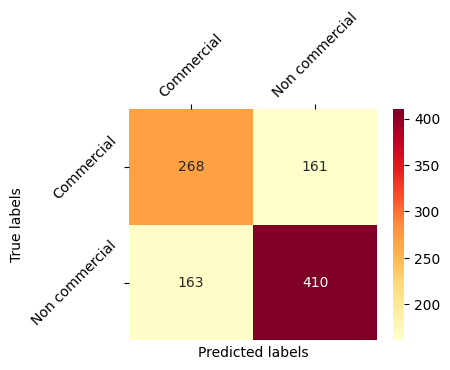

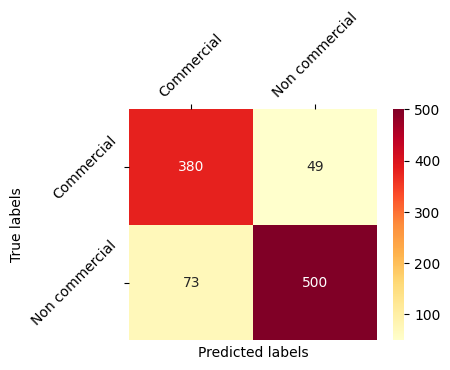

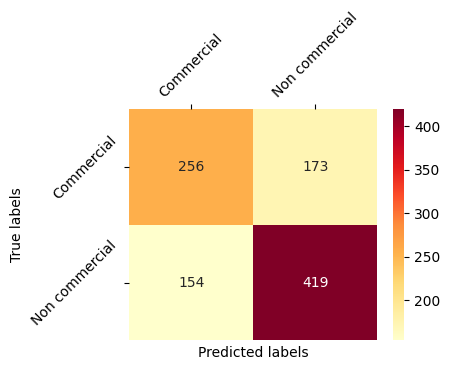

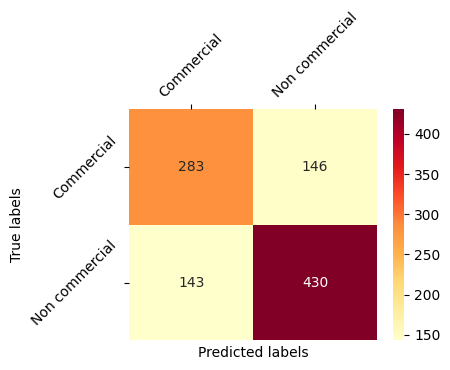

In [58]:
print (color.BOLD+f"======= Confusion Matrix of best Models  =============\n"+color.END)
for i,model in enumerate(models):
    models_confusion_matrix(model,model_names[i])

## Feature Visualization

In [59]:
from keras.utils import to_categorical
y_train=to_categorical(train_data['Label'])
y_test=to_categorical(test_data['Label'])

In [61]:

# Load the saved model
model=load_model(models_path+'Models_3/'+ 'XceptionBiLSTM.h5')
y_pred = np.argmax(model.predict([test_image,test_pad_sequences]), axis=-1)

32/32 [==============================] - 9s 71ms/step


In [62]:
model = load_model(models_path+'Models_3/'+ 'XceptionLSTM.h5')
for layer in model.layers:
    print(layer.name, layer.trainable)
    print('Layer Configuration:')
    print(layer.get_config(), end='\n{}\n'.format('----'*10))

input_1 True
Layer Configuration:
{'batch_input_shape': (None, 150, 150, 3), 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'input_1'}
----------------------------------------
block1_conv1 False
Layer Configuration:
{'name': 'block1_conv1', 'trainable': False, 'dtype': 'float32', 'filters': 32, 'kernel_size': (3, 3), 'strides': (2, 2), 'padding': 'valid', 'data_format': 'channels_last', 'dilation_rate': (1, 1), 'groups': 1, 'activation': 'linear', 'use_bias': False, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}
----------------------------------------
block1_conv1_bn False
Layer Configuration:
{'name': 'block1_conv1_bn', 'trainable':

In [64]:
def create_truncated_model(trained_model):

    #model = load_model(folder_path+'Models_2/'+'vgg16.h5')
    #
    for i, layer in enumerate(model.layers):
        layer.set_weights(trained_model.layers[i].get_weights())
    model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    return model

# model = create_lstm_attention_resnet_model()
# model.load_weights(folder_path+'Models_2/'+ 'resnet_lstm_att.h5')

model = load_model(models_path+'Models_3/'+'resnetBiLSTM.h5')

truncated_model = create_truncated_model(model)
hidden_features = truncated_model.predict([test_image,test_pad_sequences])

32/32 [==============================] - 6s 91ms/step


In [65]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pca = PCA(n_components=2)
pca_result = pca.fit_transform(hidden_features)
print('Variance PCA: {}'.format(np.sum(pca.explained_variance_ratio_)))
##Variance PCA: 0.993621154832802

#Run T-SNE on the PCA features.
tsne = TSNE(n_components=2, perplexity=20, verbose = 1)
tsne_results = tsne.fit_transform(pca_result)

Variance PCA: 1.0
[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 1002 samples in 0.004s...
[t-SNE] Computed neighbors for 1002 samples in 0.008s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1002
[t-SNE] Computed conditional probabilities for sample 1002 / 1002
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 37.384880
[t-SNE] KL divergence after 1000 iterations: -1.143273


In [66]:
pip install keras.utils

  Preparing metadata (setup.py) ... done
  Created wheel for keras.utils: filename=keras_utils-1.0.13-py3-none-any.whl size=2631 sha256=a01a95929d5117b79275bca2b51175bfcf1dedd9609b91f805039d334258aabf
  Stored in directory: /root/.cache/pip/wheels/5c/c0/b3/0c332de4fd71f3733ea6d61697464b7ae4b2b5ff0300e6ca7a
Successfully built keras.utils


IndexError: list index out of range

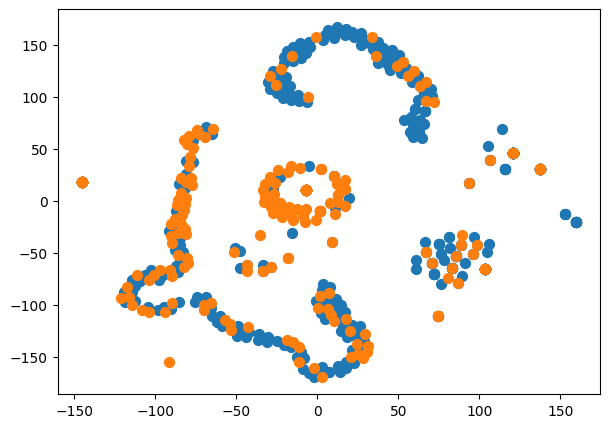

In [67]:
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
%matplotlib inline

y_test_cat = to_categorical(test_data['Label'], num_classes = 2)
color_map = np.argmax(y_test_cat, axis=1)
plt.figure(figsize=(7,5))
class_labels = ['Commercial', 'Non commercial']
for i,cl in enumerate(range(7)):
    indices = np.where(color_map==cl)
    indices = indices[0]
    plt.scatter(tsne_results[indices,0], tsne_results[indices, 1], label=class_labels[i],marker='o',s=50)
plt.title('Feature visulaiztion of a multimodal model resnet_LSTM')
plt.legend()
plt.savefig(folder_path+'fv.png',dpi = 700,bbox_inches ='tight')
plt.show()



In [ ]:
# from keras.utils import np_utils
# import matplotlib.pyplot as plt
# %matplotlib inline

# y_test_cat = np_utils.to_categorical(test_data['enc_label'], num_classes = 7)
# color_map = np.argmax(y_test_cat, axis=1)
# plt.figure(figsize=(7,5))
# class_labels = ['happy','angry','disgust','fear','sad','surprise','other']
# for i,cl in enumerate(range(7)):
#     indices = np.where(color_map==cl)
#     indices = indices[0]
#     plt.scatter(tsne_results[indices,0], tsne_results[indices, 1], label=class_labels[i],marker='o',s=50)
# plt.title('Feature visulaiztion of the proposed model (with attention)')
# plt.legend()
# plt.savefig(folder_path+'fv-a.png',dpi = 700,bbox_inches ='tight')
# plt.show()



In [68]:
tf.keras.backend.clear_session()

In [69]:
text_models_list

In [72]:
### Multimodal models with Inception

visual_model_name = ['inception']
visual_models_list = [inception_model()]

# textual_model_name = ['LSTM','CNN', 'LSTM-CNN']
textual_model_name = ['LSTM', 'CNN', 'GRU','BiLSTM']
text_models_list = create_keras_embeddings_models(180)

# keras.backend.clear_session()

# for vm,visual_model in enumerate(visual_models_list):
#   for tm,textual_model in enumerate(text_models_list):
#     # Concatenating the output of 2 classifiers
#     con_layer = keras.layers.concatenate([visual_model.output, textual_model.output])
#     #dropout = Dropout(0.2)(con_layer)
#     #final_dense = Dense(64, activation="relu")(dropout)
#     out = Dense(6,activation='softmax')(con_layer)

#     #Defining model input and output
#     com_model = Model(inputs = [visual_model.input, textual_model.input], outputs=out)

#     com_model.compile(loss='sparse_categorical_crossentropy', optimizer=RMSprop(), metrics = ["accuracy"])
#     print(f"Model Name: {visual_model_name[vm]}+{textual_model_name[tm]}\n")
#     com_model.fit([train_image,train_pad_sequences],
#     train_data['enc_label'],
#     epochs=50,
#     batch_size =64,
#     validation_split=0.1,
#     verbose =1,
#     callbacks = callbacks_check(visual_model_name[vm] + textual_model_name[tm]))


# visual_model = inception_model()
# textual_model = text_models_list[2]

# # Concatenating the output of 2 classifiers
# con_layer = keras.layers.concatenate([visual_model.output, textual_model.output])
# #dropout = Dropout(0.2)(con_layer)
# #final_dense = Dense(64, activation="relu")(dropout)
# out = Dense(7,activation='softmax')(con_layer)

#     #Defining model input and output
# com_model = Model(inputs = [visual_model.input, textual_model.input], outputs=out)

# com_model.compile(loss='sparse_categorical_crossentropy', optimizer=RMSprop(), metrics = ["accuracy"])
#     #print(f"Model Name: {visual_model_name[vm]}+{textual_model_name[tm]}\n")
# com_model.fit([train_image,train_pad_sequences],
#   train_data['enc_label'],
#     epochs=50,
#     batch_size =32,
#     validation_data=([valid_image,valid_pad_sequences],y_valid),
#     verbose =1,
#     callbacks = callbacks_check('inception+bilstm-CNN'))





87910968/87910968 [==============================] - 5s 0us/step


In [75]:

keras.backend.clear_session()
for vm,visual_model in enumerate(visual_models_list):
  for tm,textual_model in enumerate(text_models_list):
    # Concatenating the output of 2 classifiers
    keras.backend.clear_session()
    con_layer = keras.layers.concatenate([visual_model.output, textual_model.output])
    dropout = Dropout(0.2)(con_layer)
    final_dense = Dense(64, activation="relu")(dropout)
    out = Dense(2,activation='softmax')(final_dense)

    #Defining model input and output
    com_model = Model(inputs = [visual_model.input, textual_model.input], outputs=out)
    if visual_model == 'vgg16':
      opt = RMSprop()
    else:
      opt = Adam()

    com_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics = ["accuracy"])
    print(f"Model Name: {visual_model_name[vm]}+{textual_model_name[tm]}\n")
    com_model.fit([train_image,train_pad_sequences],
    y_train,
    epochs=10,
    batch_size =64,
    validation_data=([valid_image,valid_pad_sequences],y_valid),
    verbose =1,
    class_weight = class_weights,
    callbacks = callbacks_check(visual_model_name[vm]+textual_model_name[tm]))

ValueError: The name "concatenate" is used 2 times in the model. All layer names should be unique.

In [77]:
print(text_models_list)

[<keras.src.engine.sequential.Sequential object at 0x78561999c0d0>, <keras.src.engine.sequential.Sequential object at 0x7856f1890bb0>, <keras.src.engine.sequential.Sequential object at 0x7856f1891960>, <keras.src.engine.sequential.Sequential object at 0x7856f00d50c0>]


In [76]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Conv1D, MaxPooling1D, Flatten, GRU, Bidirectional, Input, Dropout, GlobalAveragePooling2D, concatenate

def create_keras_embeddings_models(max_len):
    models = []

    # Function to create the embedding layer
    def embedding_layer(name):
        return Embedding(input_dim=1000, output_dim=64, input_length=max_len, name=name)

    # 1. LSTM Model
    lstm_model = Sequential(name='LSTM_Model')
    lstm_model.add(Input(shape=(max_len,), name='lstm_input'))
    lstm_model.add(embedding_layer('lstm_embedding'))
    lstm_model.add(LSTM(units=64, name='lstm_lstm'))
    lstm_model.add(Dense(units=2, activation="softmax", name='lstm_output'))
    models.append(lstm_model)

    # 2. CNN Model
    cnn_model = Sequential(name='CNN_Model')
    cnn_model.add(Input(shape=(max_len,), name='cnn_input'))
    cnn_model.add(embedding_layer('cnn_embedding'))
    cnn_model.add(Conv1D(filters=64, kernel_size=3, activation="relu", name='cnn_conv1d'))
    cnn_model.add(MaxPooling1D(pool_size=2, name='cnn_maxpool'))
    cnn_model.add(Flatten(name='cnn_flatten'))
    cnn_model.add(Dense(units=2, activation="softmax", name='cnn_output'))
    models.append(cnn_model)

    # 3. GRU Model
    gru_model = Sequential(name='GRU_Model')
    gru_model.add(Input(shape=(max_len,), name='gru_input'))
    gru_model.add(embedding_layer('gru_embedding'))
    gru_model.add(GRU(units=128, name='gru_gru'))  # GRU layer
    gru_model.add(Dense(units=2, activation="softmax", name='gru_output'))
    models.append(gru_model)

    # 4. BiLSTM Model
    bilstm_model = Sequential(name='BiLSTM_Model')
    bilstm_model.add(Input(shape=(max_len,), name='bilstm_input'))
    bilstm_model.add(embedding_layer('bilstm_embedding'))
    bilstm_model.add(Bidirectional(LSTM(units=64, return_sequences=True), name='bilstm_bilstm1'))
    bilstm_model.add(Bidirectional(LSTM(units=64), name='bilstm_bilstm2'))  # Deeper processing
    bilstm_model.add(Dense(units=2, activation="softmax", name='bilstm_output'))
    models.append(bilstm_model)

    return models

def create_visual_model():
    image_size = (150, 150, 3)

    inception = tf.keras.applications.InceptionV3(
        weights='imagenet', include_top=False, input_shape=image_size
    )
    for layer in inception.layers[:-10]:  # Freeze the last 10 layers for InceptionV3
        layer.trainable = False

    pool_i = GlobalAveragePooling2D(name='inception_global_avg_pool')(inception.output)
    output_i = Dense(2, activation='softmax', name='inception_output_dense')(pool_i)
    inception_img_model = Model(inputs=inception.input, outputs=output_i, name='inception_model')

    return inception_img_model

def combine_models(visual_model, textual_model, index):
    # Ensure both models are instantiated and have outputs
    visual_input = Input(shape=(150, 150, 3), name=f'visual_input_{index}')
    textual_input = Input(shape=(100,), name=f'textual_input_{index}')

    visual_output = visual_model(visual_input)
    textual_output = textual_model(textual_input)

    combined_input = concatenate([visual_output, textual_output], name=f'concatenate_{index}')
    combined_dropout = Dropout(0.5, name=f'combined_dropout_{index}')(combined_input)
    combined_dense = Dense(64, activation='relu', name=f'combined_dense_{index}')(combined_dropout)
    combined_output = Dense(2, activation='softmax', name=f'combined_output_{index}')(combined_dense)

    combined_model = Model(inputs=[visual_input, textual_input], outputs=combined_output, name=f'combined_model_{index}')

    return combined_model

# Example usage
max_len = 100
text_models_list = create_keras_embeddings_models(max_len)
visual_model = create_visual_model()

# Combine each text model with the visual model
for i, textual_model in enumerate(text_models_list):
    combined_model = combine_models(visual_model, textual_model, i)
    combined_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    print(f"Model Name: {visual_model_name[vm]}+{textual_model_name[tm]}\n")
    com_model.fit([train_image,train_pad_sequences],
    y_train,
    epochs=10,
    batch_size =64,
    validation_data=([valid_image,valid_pad_sequences],y_valid),
    verbose =1,
    class_weight = class_weights,
    callbacks = callbacks_check(visual_model_name[vm]+textual_model_name[tm]))
    #combined_model.summary()

    # Example training code (replace with actual data and parameters)
    # combined_model.fit([train_image, train_pad_sequences], y_train, epochs=10, batch_size=64, validation_data=([valid_image, valid_pad_sequences], y_valid))


Model Name: inception+LSTM

Epoch 1/10
47/47 [==============================] - ETA: 0s - loss: 0.2369 - accuracy: 0.8974
Epoch 1: val_accuracy improved from -inf to 0.70030, saving model to /content/drive/MyDrive/Research/Anik/MultimodalModels_3/inceptionLSTM.h5
47/47 [==============================] - 16s 314ms/step - loss: 0.2369 - accuracy: 0.8974 - val_loss: 0.6203 - val_accuracy: 0.7003
Epoch 2/10
47/47 [==============================] - ETA: 0s - loss: 0.1898 - accuracy: 0.9217
Epoch 2: val_accuracy did not improve from 0.70030
47/47 [==============================] - 11s 228ms/step - loss: 0.1898 - accuracy: 0.9217 - val_loss: 0.6578 - val_accuracy: 0.6244
Epoch 3/10
47/47 [==============================] - ETA: 0s - loss: 0.1693 - accuracy: 0.9247
Epoch 3: val_accuracy improved from 0.70030 to 0.74426, saving model to /content/drive/MyDrive/Research/Anik/MultimodalModels_3/inceptionLSTM.h5
47/47 [==============================] - 14s 306ms/step - loss: 0.1693 - accuracy: 0.924

In [78]:
# multimodal_models = ['inceptionLSTM','inceptionCNN','inceptionLSTM-CNN']
# multimodal_names =  ['inception+LSTM','inception+CNNText','inception+LSTM-CNN']
multimodal_models = ['inceptionLSTM', 'inceptionCNN', 'inceptionGRU', 'inceptionBiLSTM']
multimodal_names =  ['inception+LSTM', 'inception+CNN', 'inception+GRU','inception+BiLSTM']

def multimodal_models_accuracy(saved_model):
  my_dict = {}
  # Prediction
  model = load_model(models_path+'Models_3/'+f"{saved_model}.h5")
  y_pred = np.argmax(model.predict([test_image,test_pad_sequences]), axis=-1)

  y_true = test_data['Label']

  my_dict['Accuracy'] = accuracy_score(y_true, y_pred)*100
  my_dict['Precision'] = precision_score(y_true, y_pred,average = 'weighted')*100
  my_dict['Recall'] = recall_score(y_true, y_pred,average = 'weighted')*100
  my_dict['F1 Score'] = f1_score(y_true, y_pred,average = 'weighted')*100
  return my_dict

In [1]:
accuracy = {f'{multimodal_names[i]}':multimodal_models_accuracy(model) for i,model in enumerate(multimodal_models)}
# Save the performance parameter into json file
with open(models_path+'Results_3/'+'multimodal_models_performance.json', 'w') as f:
    json.dump(accuracy, f)

NameError: name 'multimodal_models' is not defined

In [80]:
# Load the json file
metrics = json.load(open(models_path+'Results_3/'+'multimodal_models_performance.json'))
acc_list = []
pr_list = []
re_list = []
f1_list = []
for i in metrics.keys():
  acc_list.append(round(metrics[i]['Accuracy'],2))
  pr_list.append(round(metrics[i]['Precision'],2))
  re_list.append(round(metrics[i]['Recall'],2))
  f1_list.append(round(metrics[i]['F1 Score'],2))

print (color.BOLD+f"=======  Multimodal Models Performance on Test Data  =============\n"+color.END)
# Create a dataframe
performance_matrix = pd.DataFrame({'Accuracy':acc_list,'Precision':pr_list,
                                   'Recall':re_list,'F1 Score':f1_list},
                                  index =multimodal_names)
performance_matrix

=======  Multimodal Models Performance on Test Data  =============



,Accuracy,Precision,Recall,F1 Score
inception+LSTM,67.66,67.68,67.66,67.67
inception+CNN,87.82,88.00,87.82,87.86
inception+GRU,67.37,67.21,67.37,67.26
inception+BiLSTM,71.16,71.13,71.16,71.14


In [83]:
# models = ['inceptionLSTM','inceptionCNN','inceptionLSTM-CNN']
# model_names = ['inception+LSTM','inception+CNNText','inception+LSTM-CNN']
model = ['inceptionLSTM', 'inceptionCNN', 'inceptionGRU', 'inceptionBiLSTM']
model_names =  ['inception+LSTM', 'inception+CNN', 'inception+GRU','inception+BiLSTM']
class_names = ['Commercial', 'Non commercial']
def models_confusion_matrix(saved_model,model_name):

  # if saved_model == 'vgg16LSTM':
    # model = visual_models()
    model=load_model(models_path+'Models_3/'+f"{saved_model}.h5")
    y_pred = np.argmax(model.predict([test_image,test_pad_sequences]), axis=-1)




    y_true = test_data['Label']
    con_mat(y_true,y_pred,class_names,model_name)


======= Confusion Matrix of best Models  =============

32/32 [==============================] - 5s 69ms/step


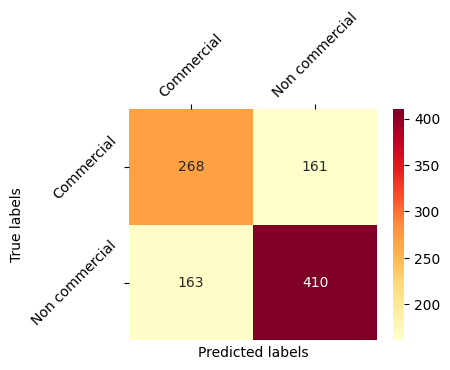

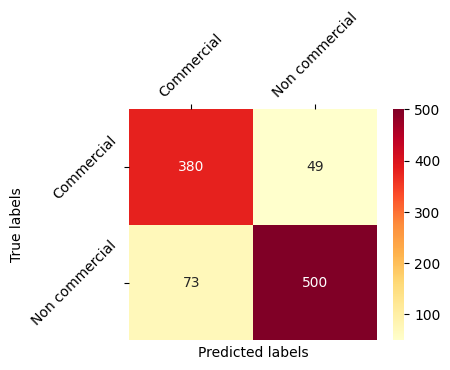

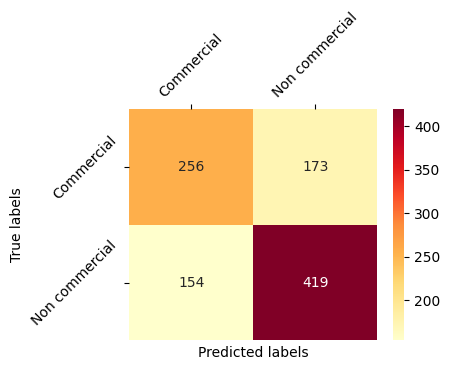

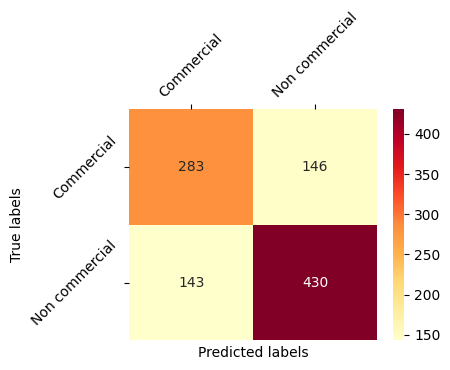

In [84]:
print (color.BOLD+f"======= Confusion Matrix of best Models  =============\n"+color.END)
for i,model in enumerate(models):
    models_confusion_matrix(model,model_names[i])

In [86]:
from sklearn.metrics import matthews_corrcoef

multimodal_models = ['vgg16LSTM','vgg16CNN','resnetLSTM','resnetCNN','inceptionLSTM','inceptionCNN']
multimodal_names =  ['VGG16+LSTM','VGG16+CNNText','ResNet+LSTM','ResNet+CNNText','inception+LSTM','inception+CNNText']
class_names = ['happy', 'angry', 'disgust', 'fear', 'sad', 'surprise', 'other']

def multimodal_models_metrics_MCC(saved_model, model_name):
  model = load_model(models_path + 'Models_3/' + f"{saved_model}.h5")
  y_pred = np.argmax(model.predict([test_image,test_pad_sequences]), axis=-1)
  y_true = test_data['Label']



  # Calculate MCC
  mcc = matthews_corrcoef(y_true, y_pred)
  print(f"MCC for {model_name}: {mcc}")

print(f"{color.BOLD}======= Matrices for Visual Models  ============={color.END}")
for i, model in enumerate(multimodal_models):
  multimodal_models_metrics_MCC(model, multimodal_names[i])

======= Matrices for Visual Models  =============
32/32 [==============================] - 3s 64ms/step
MCC for VGG16+LSTM: 0.0
32/32 [==============================] - 3s 63ms/step
MCC for VGG16+CNNText: 0.7424016082441042
32/32 [==============================] - 3s 53ms/step
MCC for ResNet+LSTM: 0.5788373846496273
32/32 [==============================] - 3s 51ms/step
MCC for ResNet+CNNText: 0.7815150554724491
32/32 [==============================] - 4s 66ms/step
MCC for inception+LSTM: 0.34705052057516916


OSError: No file or directory found at /content/drive/MyDrive/Research/Anik/MultimodalModels_3/inceptionCNN.h5